# 0. Revisión Inicial

## N registros: 209527

In [37]:
import pandas as pd

url = "https://raw.githubusercontent.com/m4ck-y/ml-headline-classification/refs/heads/main/data/data.json"
df_original = pd.read_json(url)

print(df_original.head())
print(df_original.shape)
print(df_original.info())

n_original_instances = len(df_original)
print("Numero de registros(df_original):", n_original_instances)

                                            headline   category
0  Over 4 Million Americans Roll Up Sleeves For O...  U.S. NEWS
1  American Airlines Flyer Charged, Banned For Li...  U.S. NEWS
2  23 Of The Funniest Tweets About Cats And Dogs ...     COMEDY
3  The Funniest Tweets From Parents This Week (Se...  PARENTING
4  Woman Who Called Cops On Black Bird-Watcher Lo...  U.S. NEWS
(209527, 2)
<class 'pandas.core.frame.DataFrame'>
Index: 209527 entries, 0 to 209526
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   headline  209527 non-null  object
 1   category  209527 non-null  object
dtypes: object(2)
memory usage: 4.8+ MB
None
Numero de registros(df_original): 209527


## N Categories: 42

In [38]:
n_original_categories = df_original['category'].nunique()
count_by_category_original = df_original['category'].value_counts()

print("Numero de categorias(df_original):", n_original_categories)
print("N registros/Categoria(df_original):\n", count_by_category_original)

Numero de categorias(df_original): 42
N registros/Categoria(df_original):
 category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
COMEDY             5400
SPORTS             5077
BLACK VOICES       4583
HOME & LIVING      4320
PARENTS            3955
THE WORLDPOST      3664
WEDDINGS           3653
WOMEN              3572
CRIME              3562
IMPACT             3484
DIVORCE            3426
WORLD NEWS         3299
MEDIA              2944
WEIRD NEWS         2777
GREEN              2622
WORLDPOST          2579
RELIGION           2577
STYLE              2254
SCIENCE            2206
TECH               2104
TASTE              2096
MONEY              1756
ARTS               1509
ENVIRONMENT        1444
FIFTY              1401
GOOD NEWS          1398
U.S. NEWS          1377
ARTS & CULTURE     1339
COLL

# 1 Limpieza de datos

## 1.1 Normalizacion de texto

In [39]:
# Crear una copia del DataFrame original para no modificar los datos originales
df_cleaned = df_original.copy()

#Convertir texto a formato consistente
df_cleaned['headline'] = df_cleaned['headline'].str.lower()
df_cleaned['category'] = df_cleaned['category'].str.upper()

In [40]:
# procesar fechas en headlines
# porque el objetivo es entender el tema o categoría del contenido, no cuándo ocurrió(ruido)

import re

# Regex para detectar fechas en varios formatos comunes (mes+días, años, días con sufijos)
date_pattern = re.compile(
    r'\b(?:Jan(?:uary)?|Feb(?:ruary)?|Mar(?:ch)?|Apr(?:il)?|'
    r'May|Jun(?:e)?|Jul(?:y)?|Aug(?:ust)?|Sep(?:t(?:ember)?)?|'
    r'Oct(?:ober)?|Nov(?:ember)?|Dec(?:ember)?)\s+\d{1,2}(?:[-–]\d{1,2})?\b'
    r'|\b(19|20)\d{2}\b'
    r'|\b\d{1,2}(st|nd|rd|th)\b',
    flags=re.IGNORECASE
)

# Función para detectar si hay fechas en un texto (devuelve True o False)
def has_date(text):
    return bool(date_pattern.search(text))

# Función para eliminar fechas del texto
def remove_dates(text):
    text = date_pattern.sub('', text)
    text = re.sub(r'\s+', ' ', text)  # limpiar espacios extras
    return text.strip()

In [41]:
df_with_dates = df_original[df_original['headline'].apply(has_date)]
print("headline con fechas", len(df_with_dates))
df_with_dates["headline"]

headline con fechas 6741


,headline
29,'French Spider-Man' Celebrates 60th Birthday W...
31,Watchdog Report Finds Some Census Takers Who F...
39,Amazon Greenlights 'Blade Runner 2099' Limited...
56,U.S. Inflation Falls For 2nd Straight Month On...
67,Carlos Alcaraz Wins U.S. Open For 1st Slam Tit...
...,...
209449,"Bow Wow Has Tax Liens From 2006, 2008, And 2010"
209452,Data Privacy Day -- Version 2012
209458,Novak Djokovic vs. Rafael Nadal: LIVE UPDATES ...
209496,Something To Celebrate: The Best LGBT Moments ...


In [42]:
# solo para evaluar el headline al aplicar remove_dates
df_without_dates = df_with_dates.copy()
df_without_dates["headline"] = df_without_dates["headline"].apply(remove_dates)
df_without_dates["headline"]

,headline
29,'French Spider-Man' Celebrates Birthday With A...
31,Watchdog Report Finds Some Census Takers Who F...
39,Amazon Greenlights 'Blade Runner ' Limited Ser...
56,U.S. Inflation Falls For Straight Month On Low...
67,"Carlos Alcaraz Wins U.S. Open For Slam Title, ..."
...,...
209449,"Bow Wow Has Tax Liens From , , And"
209452,Data Privacy Day -- Version
209458,Novak Djokovic vs. Rafael Nadal: LIVE UPDATES ...
209496,Something To Celebrate: The Best LGBT Moments ...


In [43]:
# eliminar fechas
df_cleaned["headline"] = df_cleaned["headline"].apply(remove_dates)

In [44]:
# Esto elimina espacios en blanco al inicio y al final de cada string en esas columnas
def clean_text(txt:str):
  # Reemplaza saltos de línea y retornos de carro
  txt = txt.replace("\n", " ").replace("\r", " ")
  # Elimina caracteres que no sean alfanuméricos, espacios o '&'
  txt = "".join(char for char in txt if char.isalnum() or char.isspace() or char == '&')
  # Elimina espacios en blanco sobrantes
  return txt.strip()

df_cleaned['headline'] = df_cleaned['headline'].apply(clean_text)
df_cleaned['category'] = df_cleaned['category'].apply(clean_text)

df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 209527 entries, 0 to 209526
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   headline  209527 non-null  object
 1   category  209527 non-null  object
dtypes: object(2)
memory usage: 4.8+ MB


## 1.2 Filtrado de Valores vacios '' , NaN, null


In [45]:
#Encontrar valores vacios
df_with_empty_rows = df_cleaned[
    (df_cleaned['headline'].isna()) | (df_cleaned['category'].isna()) |
    (df_cleaned['headline'] == '')  | (df_cleaned['category'] == '')
]

n_empty_rows = len(df_with_empty_rows)

print("Numero de registros con datos vacios:", n_empty_rows)
print(df_with_empty_rows)

Numero de registros con datos vacios: 9
       headline      category
90944                POLITICS
95567                RELIGION
103675              WORLDPOST
109100               BUSINESS
110153                  MEDIA
111413                PARENTS
121376                 IMPACT
122145           QUEER VOICES
123903               POLITICS


In [46]:
# Eliminar valores vacios econtrados

df_cleaned = df_cleaned.drop(df_with_empty_rows.index)

n_after_delete_empty_rows = len(df_cleaned)

print("N Registros, df_original:", n_original_instances)
print("N Registros vacios:", n_empty_rows)
print("N Registros despues de eliminar vacios:", n_after_delete_empty_rows)

N Registros, df_original: 209527
N Registros vacios: 9
N Registros despues de eliminar vacios: 209518


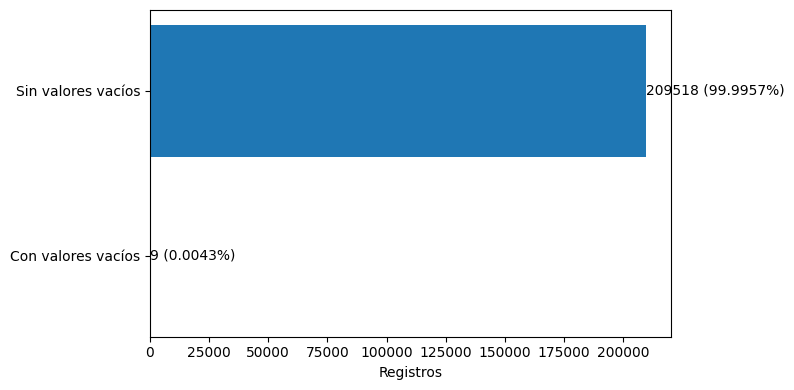

In [47]:
import matplotlib.pyplot as plt

n_non_empty_rows = n_original_instances - n_empty_rows

labels = ['Con valores vacíos', 'Sin valores vacíos']
values = [n_empty_rows, n_non_empty_rows]

plt.figure(figsize=(8, 4))
bars = plt.barh(labels, values)

#Etiquetas con conteo + porcentaje
total = sum(values)
for bar in bars:
    width = bar.get_width()
    pct = (width / total) * 100
    label = f'{int(width)} ({pct:.4f}%)'
    plt.text(width + 100, bar.get_y() + bar.get_height()/2, label, va='center')

plt.xlabel('Registros')
plt.tight_layout()
plt.show()


## 1.3 Registros Duplicados

In [48]:
#Duplicados - todas las columnas iguales
df_duplicates = df_cleaned[df_cleaned.duplicated()]

n_duplicates_rows = len(df_duplicates)

count_by_category_duplicates = df_duplicates['category'].value_counts()

print("Numero de registros duplicados:", n_duplicates_rows)

Numero de registros duplicados: 1970


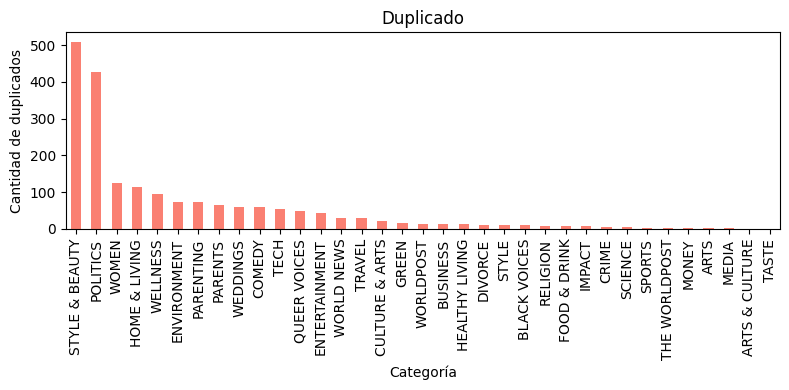

In [49]:
import matplotlib.pyplot as plt
#duplicados por categoría
count_by_category_duplicates.plot(kind='bar', figsize=(8,4), color='salmon')
plt.title('Duplicado')
plt.xlabel('Categoría')
plt.ylabel('Cantidad de duplicados')
plt.tight_layout()
plt.show()

In [50]:
# Eliminar duplicados apartir de df_cleaned(ya se eliminaron previamente valores vacios)
df_cleaned = df_cleaned.drop_duplicates()

n_after_delete_duplicated_rows = len(df_cleaned)

print("N Registros, df_original:", n_original_instances)
print("N Registros vacios:", n_empty_rows)
print("N Registros despues de eliminar vacios:", n_after_delete_empty_rows)
print("N Registros duplicados(en df_cleaned[deleted empty]):", n_duplicates_rows)
print("N Registros despues de eliminar duplicados:", n_after_delete_duplicated_rows)

N Registros, df_original: 209527
N Registros vacios: 9
N Registros despues de eliminar vacios: 209518
N Registros duplicados(en df_cleaned[deleted empty]): 1970
N Registros despues de eliminar duplicados: 207548


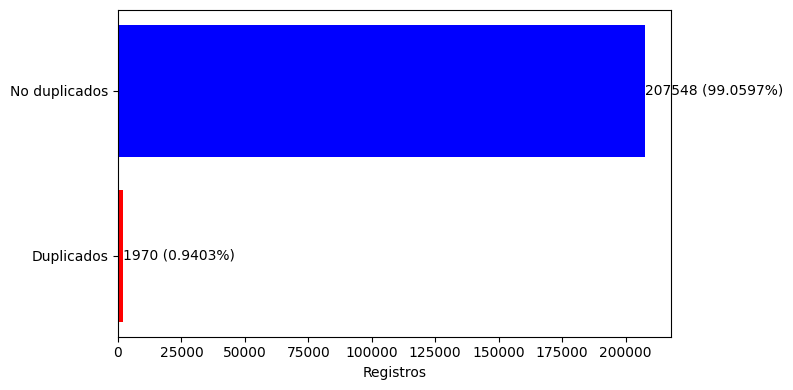

In [51]:
import matplotlib.pyplot as plt

n_non_duplicates = n_after_delete_empty_rows - n_duplicates_rows

# Datos para gráfico
labels = ['Duplicados', 'No duplicados']
values = [n_duplicates_rows, n_non_duplicates]

plt.figure(figsize=(8, 4))
bars = plt.barh(labels, values, color=["red", "blue"])

# Etiquetas con conteo + porcentaje
total = sum(values)
for bar in bars:
    width = bar.get_width()
    pct = (width / total) * 100
    label = f'{int(width)} ({pct:.4f}%)'
    plt.text(width + 100, bar.get_y() + bar.get_height() / 2, label, va='center')

plt.xlabel('Registros')
plt.tight_layout()
plt.show()


In [52]:
df_issues = pd.concat([df_with_empty_rows, df_duplicates])

n_issues = len(df_issues)

print("n_issues:", n_issues)

print(f"Porcentaje con problemas: {n_issues / n_original_instances * 100:.4f}%")

n_issues: 1979
Porcentaje con problemas: 0.9445%


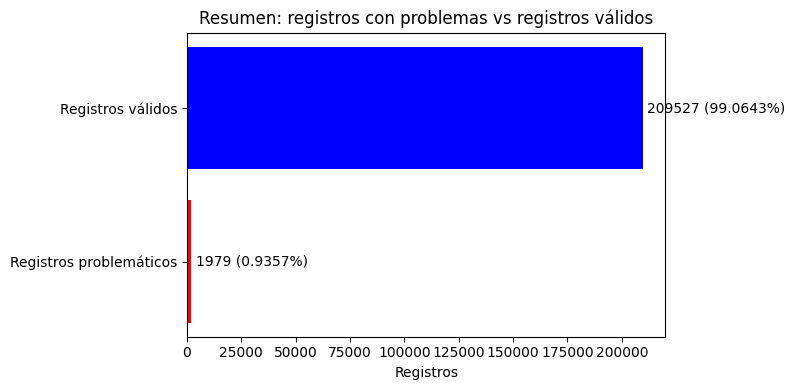

In [53]:
import matplotlib.pyplot as plt

labels = ['Registros problemáticos', 'Registros válidos']
values = [n_issues, n_original_instances]
colors = ['red', 'blue']

plt.figure(figsize=(8, 4))
bars = plt.barh(labels, values, color=colors)

# Etiquetas con conteo y porcentaje
total = sum(values)
for bar in bars:
    width = bar.get_width()
    pct = (width / total) * 100
    label = f'{int(width)} ({pct:.4f}%)'
    plt.text(width + total * 0.01, bar.get_y() + bar.get_height() / 2, label, va='center')

plt.xlabel('Registros')
plt.title('Resumen: registros con problemas vs registros válidos')
plt.tight_layout()
plt.show()


# 2 Categorias

In [54]:
n_cleaned_categories = df_cleaned['category'].nunique()
count_by_category_cleaned = df_cleaned['category'].value_counts()

print("Numero de categorias(df_original):", n_original_categories)
print("Numero de categorias(df_cleaned):", n_cleaned_categories)

Numero de categorias(df_original): 42
Numero de categorias(df_cleaned): 42


## 2.1 Categorias redundantes

In [55]:
#Encontrar categorías que contienen las mismas palabras pero en diferente orden

def normalize_category(cat):
    parts = cat.split('&')
    parts = [p.strip() for p in parts]
    parts.sort()
    return ' & '.join(parts)

# Crear columna con categorías normalizadas
df_cleaned['normalized_category'] = df_cleaned['category'].apply(normalize_category)

# Agrupar por categoría normalizada
redundant_groups = df_cleaned.groupby('normalized_category')['category'].unique()

# Filtrar solo los grupos con más de una categoría original
redundant_groups = redundant_groups[redundant_groups.apply(len) > 1]

Categorías redundantes:



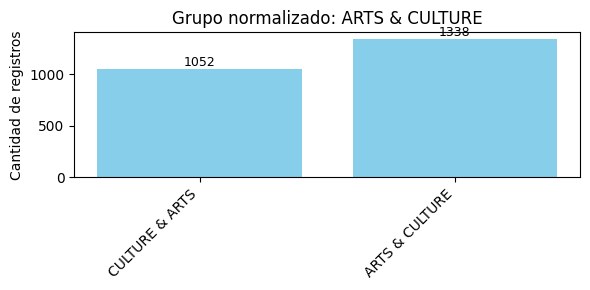

In [56]:
# Mostrar resultados
print("Categorías redundantes:\n")
# Visualizar cada grupo como gráfico de barras
for normalized_cat, original_cats in redundant_groups.items():
    cat_counts = {
        cat: (df_cleaned['category'] == cat).sum()
        for cat in original_cats
    }

    # Crear gráfico
    plt.figure(figsize=(6, 3))
    bars = plt.bar(cat_counts.keys(), cat_counts.values(), color='skyblue')

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{int(height)}',
                 ha='center', va='bottom', fontsize=9)


    plt.title(f'Grupo normalizado: {normalized_cat}')
    plt.ylabel('Cantidad de registros')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [57]:
n_normalized_categories = df_cleaned['normalized_category'].nunique()
count_by_category_normalized = df_cleaned['normalized_category'].value_counts()

print("Numero de categorias(df_original):", n_original_categories)
print("Numero de categorias(category_normalized):", n_normalized_categories)

Numero de categorias(df_original): 42
Numero de categorias(category_normalized): 41


In [58]:
#Aplicar normalizacion a la columna category
df_cleaned['category'] = df_cleaned['normalized_category']
df_cleaned.drop(columns=['normalized_category'], inplace=True)

n_after_delete_redundant_category = len(df_cleaned)

In [59]:
print("Numero de registros despues de eliminar categorias reduntantes:", n_after_delete_redundant_category)

#Comprobar tamaño de dataset(limpieza del punto 1) después de reemplazo (no debe cambiar)
print("N Cleaned[reduntant category] == N Cleaned[empty, duplicated]?", n_after_delete_redundant_category == n_after_delete_duplicated_rows)

Numero de registros despues de eliminar categorias reduntantes: 207548
N Cleaned[reduntant category] == N Cleaned[empty, duplicated]? True


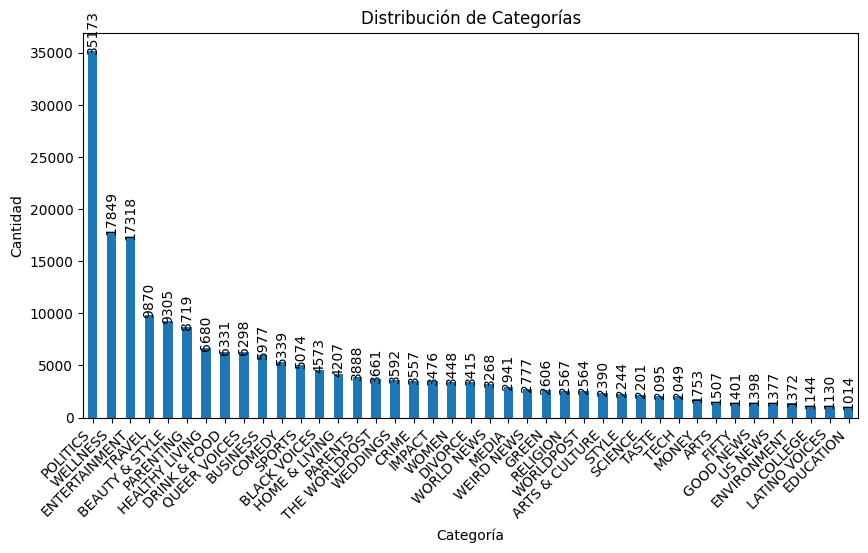

In [60]:
import matplotlib.pyplot as plt

ax = count_by_category_normalized.plot.bar(figsize=(10,5))

plt.title('Distribución de Categorías')
plt.xlabel('Categoría')
plt.ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')

# Agregar etiquetas con la cantidad encima de cada barra, en vertical
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2, height + 0.5,
            f'{int(height)}', ha='center', rotation=90)

plt.show()

In [61]:
print("Categorias mas frecuentes\n")
print(count_by_category_normalized.head())

print("\nCategorías menos frecuentes:")
print(count_by_category_normalized.tail())

Categorias mas frecuentes

normalized_category
POLITICS          35173
WELLNESS          17849
ENTERTAINMENT     17318
TRAVEL             9870
BEAUTY & STYLE     9305
Name: count, dtype: int64

Categorías menos frecuentes:
normalized_category
US NEWS          1377
ENVIRONMENT      1372
COLLEGE          1144
LATINO VOICES    1130
EDUCATION        1014
Name: count, dtype: int64


In [62]:
# Estadísticas sobre la distribución por categoría
print("Total de registros:", n_after_delete_redundant_category)
print("Total de categorías únicas:", count_by_category_normalized.shape[0])
print("Máxima cantidad por clase:", count_by_category_normalized.max())
print("Mínima cantidad por clase:", count_by_category_normalized.min())
print("Ratio max/min:", round(count_by_category_normalized.max() / count_by_category_normalized.min(), 2))
print("Media:", round(count_by_category_normalized.mean(), 2))
print("Desviación estándar:", round(count_by_category_normalized.std(), 2))


Total de registros: 207548
Total de categorías únicas: 41
Máxima cantidad por clase: 35173
Mínima cantidad por clase: 1014
Ratio max/min: 34.69
Media: 5062.15
Desviación estándar: 6114.56


In [63]:
texts = df_cleaned['headline'].tolist()

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
vectorizer.fit(texts)

print(len(vectorizer.vocabulary_))  # número total de palabras únicas

68660


# 3 Process

In [64]:
# NOTA: Esta función está diseñada únicamente para fines de entrenamiento rápido

def minimize_df(df: pd.DataFrame, n=10) -> pd.DataFrame:

    #Reduce el DataFrame a las 10 categorías menos frecuentes
    #Se usa para probar inicialmente el tiempo que tarda el modelo en entrenarse,
    #especialmente útil en entornos con recursos limitados.


    category_counts = df['category'].value_counts()

    #10 categorias con menor cantidad de rows
    rarest_categories = category_counts.nsmallest(n).index.tolist()

    # filtrar
    minimized_df = df[df['category'].isin(rarest_categories)].reset_index(drop=True)
    return minimized_df


df_process = df_cleaned.copy()
df_process = minimize_df(df_process, 15)

# 3.1 Process

In [65]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')


def process_headline(txt):
    # tokenizar en palabras
    tokens = word_tokenize(txt)

    # solo tokens alfabéticos
    tokens = [token for token in tokens if token.isalpha()]

    # eliminar stopwords
    stop_words = set(stopwords.words('english'))

    tokens = [token for token in tokens if token not in stop_words]

    return " ".join(tokens) # porque TfidfVectorizer entiende str no list

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# 3.1 Vectorizacion

In [66]:
def vectorize_texts(texts: pd.Series):
    """
    Vectoriza los textos utilizando TF-IDF.
    """
    vectorizer = TfidfVectorizer()
    X = vectorizer.fit_transform(texts)
    return X, vectorizer

In [67]:
df_process["headline"] = df_process["headline"].apply(process_headline)

X, vectorizer = vectorize_texts(df_process["headline"])

## 3.2 Conversion de categoria(clases) a number

In [68]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(df_process['category'])

# 4 Modelos

In [69]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

def apply_oversampling(X, y: pd.Series):
    # Balancea las clases utilizando oversampling

    ros = RandomOverSampler(random_state=42)
    X_resampled, y_resampled = ros.fit_resample(X, y)
    return X_resampled, y_resampled

def apply_undersampling(X, y: pd.Series):
    # Balancea las clases utilizando submuestreo (undersampling)

    rus = RandomUnderSampler(random_state=42)
    X_resampled, y_resampled = rus.fit_resample(X, y)
    return X_resampled, y_resampled

In [70]:

from sklearn.model_selection import train_test_split

def split_data(X, y, test_size=0.2, random_state=42):
    #dividir entrenamiento y prueba

    return train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=y)

# Dividir en entrenamiento y prueba, sin resampled
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded)
y_test_labels = le.inverse_transform(y_test)

# con oversampling
X_oversampling, y_oversampling = apply_oversampling(X, y_encoded)
X_train_oversampling, X_test_oversampling, y_train_oversampling, y_test_oversampling = train_test_split(X_oversampling, y_oversampling)
y_test_labels_oversampling = le.inverse_transform(y_test_oversampling)

# con undersampling
X_undersampling, y_undersampling = apply_undersampling(X, y_encoded)
X_train_undersampling, X_test_undersampling, y_train_undersampling, y_test_undersampling = train_test_split(X_undersampling, y_undersampling)
y_test_labels_undersampling = le.inverse_transform(y_test_undersampling)


## 4.1 RandomForestClassifier class_weight='balanced'





Tiempo de entrenamiento: 137.01 segundos
                precision    recall  f1-score   support

          ARTS       0.22      0.48      0.30       374
ARTS & CULTURE       0.54      0.48      0.51       602
       COLLEGE       0.62      0.59      0.60       260
     EDUCATION       0.61      0.59      0.60       261
   ENVIRONMENT       0.58      0.44      0.50       347
         FIFTY       0.46      0.48      0.47       363
     GOOD NEWS       0.57      0.44      0.50       371
 LATINO VOICES       0.84      0.51      0.63       294
         MONEY       0.66      0.60      0.63       442
       SCIENCE       0.60      0.63      0.61       516
         STYLE       0.69      0.64      0.66       552
         TASTE       0.71      0.72      0.71       518
          TECH       0.70      0.63      0.66       523
       US NEWS       0.59      0.48      0.53       355
     WORLDPOST       0.60      0.66      0.63       632

      accuracy                           0.57      6410
     

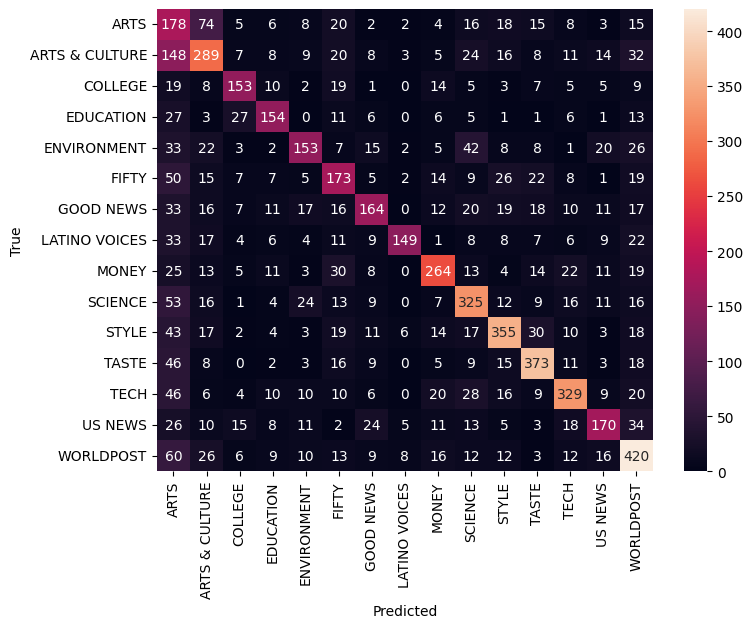

In [71]:
#Modelo random_forest
from sklearn.ensemble import RandomForestClassifier
import time
# Evaluar (por ejemplo, con accuracy)
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

def modelo_random_forest():
  start = time.time()
  # Crear el clasificador Random Forest con los parámetros indicados
  rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

  # Entrenar el modelo
  rf.fit(X_train, y_train)

  end = time.time()

  print(f"Tiempo de entrenamiento: {end - start:.2f} segundos")

  # Hacer predicciones
  y_pred = rf.predict(X_test)

  y_pred_labels = le.inverse_transform(y_pred)

  print(classification_report(y_test_labels, y_pred_labels))
  print("Accuracy:", accuracy_score(y_test, y_pred))
  print("Precision:", precision_score(y_test, y_pred, average='weighted'))
  print("Recall:", recall_score(y_test, y_pred, average='weighted'))
  print("F1-score:", f1_score(y_test, y_pred, average='weighted'))
  cm = confusion_matrix(y_test, y_pred)
  print("Matriz de confusión:")
  print(cm)

  import matplotlib.pyplot as plt
  import seaborn as sns

  labels = le.classes_

  plt.figure(figsize=(8,6))
  sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
  plt.xlabel('Predicted')
  plt.ylabel('True')
  plt.show()

modelo_random_forest()

# 4.2 RandomForestClassifier - OverSampling

Tiempo de entrenamiento: 170.86 segundos
                precision    recall  f1-score   support

          ARTS       0.60      0.76      0.67       653
ARTS & CULTURE       0.70      0.50      0.58       647
       COLLEGE       0.89      0.91      0.90       598
     EDUCATION       0.86      0.94      0.90       613
   ENVIRONMENT       0.80      0.84      0.82       652
         FIFTY       0.61      0.84      0.71       660
     GOOD NEWS       0.83      0.82      0.83       631
 LATINO VOICES       0.92      0.93      0.93       645
         MONEY       0.81      0.76      0.79       630
       SCIENCE       0.80      0.70      0.75       639
         STYLE       0.76      0.71      0.73       661
         TASTE       0.87      0.80      0.83       639
          TECH       0.83      0.78      0.80       662
       US NEWS       0.83      0.81      0.82       623
     WORLDPOST       0.73      0.62      0.67       662

      accuracy                           0.78      9615
     

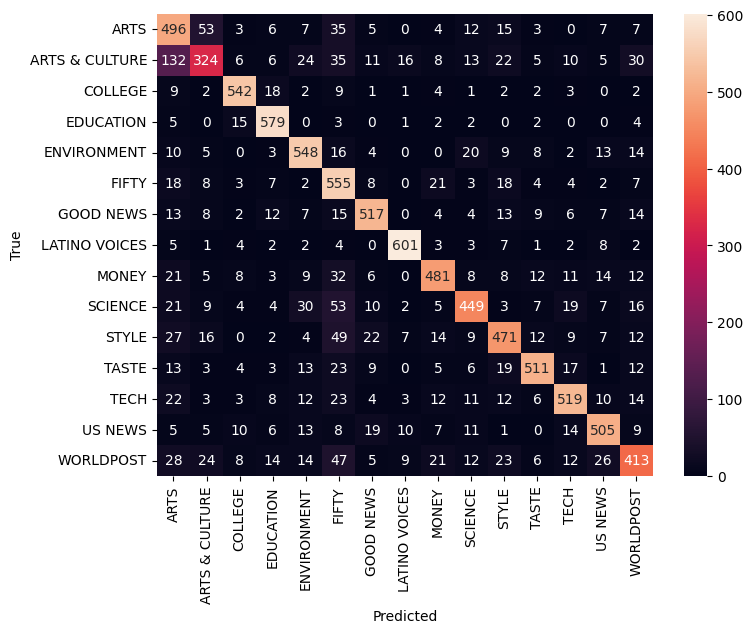

In [72]:
def modelo_random_forest_oversampling():
  start = time.time()
  # Crear el clasificador Random Forest con los parámetros indicados
  rf = RandomForestClassifier(random_state=42, n_jobs=-1)

  # Entrenar el modelo
  rf.fit(X_train_oversampling, y_train_oversampling)

  end = time.time()

  print(f"Tiempo de entrenamiento: {end - start:.2f} segundos")

  # Hacer predicciones
  y_pred = rf.predict(X_test_oversampling)

  y_pred_labels = le.inverse_transform(y_pred)



  print(classification_report(y_test_labels_oversampling, y_pred_labels))
  print("Accuracy:", accuracy_score(y_test_oversampling, y_pred))
  print("Precision:", precision_score(y_test_oversampling, y_pred, average='weighted'))
  print("Recall:", recall_score(y_test_oversampling, y_pred, average='weighted'))
  print("F1-score:", f1_score(y_test_oversampling, y_pred, average='weighted'))
  cm = confusion_matrix(y_test_oversampling, y_pred)
  print("Matriz de confusión:")
  print(cm)

  import matplotlib.pyplot as plt
  import seaborn as sns

  labels = le.classes_

  plt.figure(figsize=(8,6))
  sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
  plt.xlabel('Predicted')
  plt.ylabel('True')
  plt.show()

modelo_random_forest_oversampling()

# 4.3 RandomForestClassifier - UnderSampling

Tiempo de entrenamiento: 68.64 segundos
                precision    recall  f1-score   support

          ARTS       0.22      0.59      0.32       244
ARTS & CULTURE       0.51      0.30      0.38       257
       COLLEGE       0.64      0.52      0.58       246
     EDUCATION       0.62      0.62      0.62       248
   ENVIRONMENT       0.51      0.49      0.50       241
         FIFTY       0.41      0.52      0.45       282
     GOOD NEWS       0.49      0.43      0.46       252
 LATINO VOICES       0.70      0.54      0.61       239
         MONEY       0.64      0.60      0.62       242
       SCIENCE       0.62      0.56      0.59       256
         STYLE       0.57      0.52      0.54       258
         TASTE       0.70      0.62      0.66       279
          TECH       0.75      0.58      0.65       277
       US NEWS       0.59      0.49      0.53       244
     WORLDPOST       0.59      0.50      0.54       238

      accuracy                           0.52      3803
     m

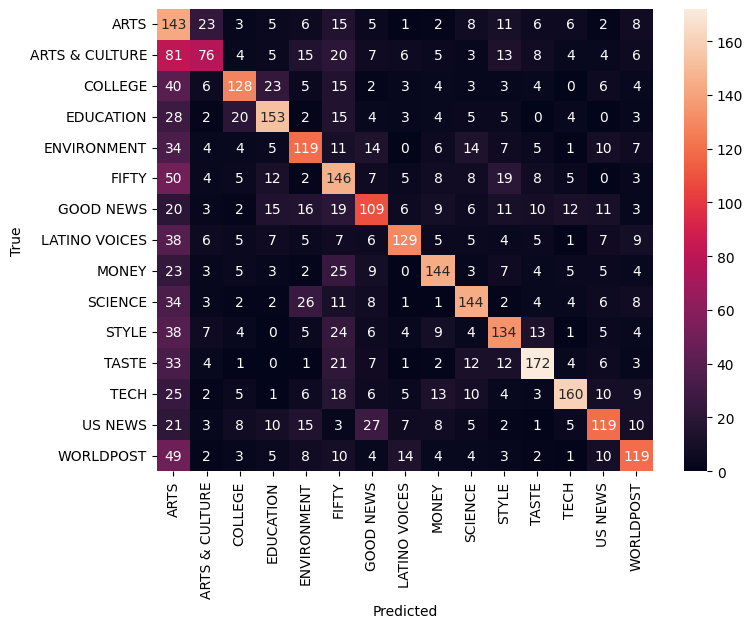

In [73]:
def modelo_random_forest_undersampling():
  start = time.time()
  # Crear el clasificador Random Forest con los parámetros indicados
  rf = RandomForestClassifier(random_state=42, n_jobs=-1)

  # Entrenar el modelo
  rf.fit(X_train_undersampling, y_train_undersampling)

  end = time.time()

  print(f"Tiempo de entrenamiento: {end - start:.2f} segundos")

  # Hacer predicciones
  y_pred = rf.predict(X_test_undersampling)

  y_pred_labels = le.inverse_transform(y_pred)

  print(classification_report(y_test_labels_undersampling, y_pred_labels))
  print("Accuracy:", accuracy_score(y_test_undersampling, y_pred))
  print("Precision:", precision_score(y_test_undersampling, y_pred, average='weighted'))
  print("Recall:", recall_score(y_test_undersampling, y_pred, average='weighted'))
  print("F1-score:", f1_score(y_test_undersampling, y_pred, average='weighted'))
  cm = confusion_matrix(y_test_undersampling, y_pred)
  print("Matriz de confusión:")
  print(cm)

  import matplotlib.pyplot as plt
  import seaborn as sns

  labels = le.classes_

  plt.figure(figsize=(8,6))
  sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
  plt.xlabel('Predicted')
  plt.ylabel('True')
  plt.show()

modelo_random_forest_undersampling()

## 4.4 Logistic Regression

Tiempo de entrenamiento: 13.26 segundos
                precision    recall  f1-score   support

          ARTS       0.47      0.26      0.33       374
ARTS & CULTURE       0.49      0.67      0.56       602
       COLLEGE       0.71      0.55      0.62       260
     EDUCATION       0.74      0.51      0.60       261
   ENVIRONMENT       0.61      0.43      0.50       347
         FIFTY       0.55      0.43      0.48       363
     GOOD NEWS       0.65      0.54      0.59       371
 LATINO VOICES       0.88      0.46      0.61       294
         MONEY       0.68      0.62      0.65       442
       SCIENCE       0.61      0.71      0.66       516
         STYLE       0.68      0.77      0.72       552
         TASTE       0.73      0.80      0.77       518
          TECH       0.71      0.69      0.70       523
       US NEWS       0.64      0.50      0.56       355
     WORLDPOST       0.50      0.82      0.62       632

      accuracy                           0.62      6410
     m

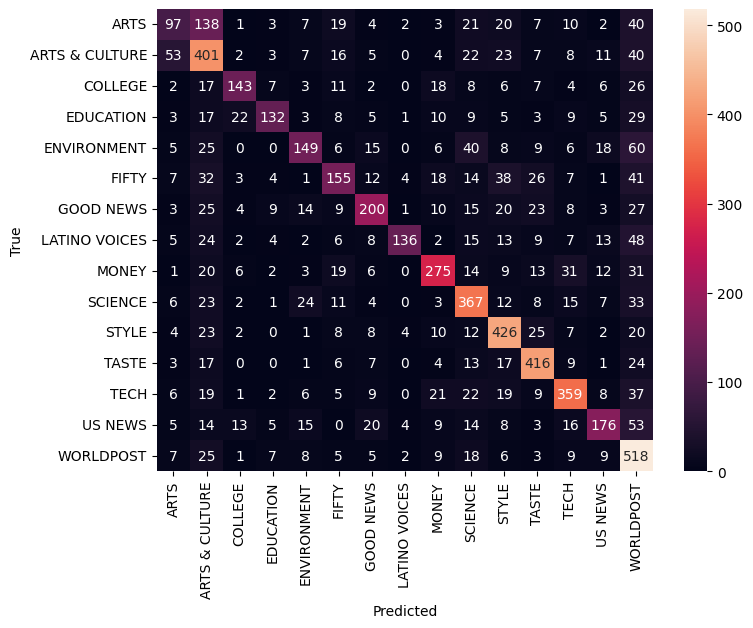

In [75]:
from sklearn.linear_model import LogisticRegression

def modelo_logistic_regression():
    start = time.time()
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    end = time.time()
    print(f"Tiempo de entrenamiento: {end - start:.2f} segundos")

    # Hacer predicciones
    y_pred = model.predict(X_test)

    y_pred_labels = le.inverse_transform(y_pred)

    print(classification_report(y_test_labels, y_pred_labels))
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, average='weighted'))
    print("Recall:", recall_score(y_test, y_pred, average='weighted'))
    print("F1-score:", f1_score(y_test, y_pred, average='weighted'))
    cm = confusion_matrix(y_test, y_pred)
    print("Matriz de confusión:")
    print(cm)

    import matplotlib.pyplot as plt
    import seaborn as sns

    labels = le.classes_

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

modelo_logistic_regression()

# 5 Modelo Final Elegido

## 5.1 RandomForestClassifier con OverSampling


-  Mejor rendimiento general
  - Accuracy: 0.78 — el más alto entre todos los modelos probados.

  - Precision / Recall / F1-Score: todos alrededor de 0.78, lo que indica un equilibrio fuerte entre identificar correctamente las clases (recall) y no equivocarse al hacerlo (precisión).

- Rendimiento robusto por clase

  - La matriz de confusión tiene menos dispersión de errores en comparación con los otros modelos.

- Generaliza bien sin perder datos
  - A diferencia de undersampling, que descarta datos, el oversampling mantiene toda la información original, lo que permite aprovechar al máximo el dataset.



In [ ]:
# La elección del modelo final se realizó utilizando un subconjunto del dataset original, limitado a las 15 categorías menos frecuentes
# debido a restricciones de recursos computacionales durante el entrenamiento.
# Si se desea probar el modelo con el dataset completo, se puede comentar la línea correspondiente en el paso 3 del código:


#df_process = minimize_df(df_process, 15)